# 03 - Transfer Learning

Comparacion de feature extraction, fine-tuning parcial y fine-tuning total con ResNet-18 preentrenada en ImageNet.

In [1]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from utils import resolve_data_dir

DATA_DIR = resolve_data_dir(ROOT / "data" / "dataset")
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def run_train(*args):
    cmd = [sys.executable, str(ROOT / "src" / "train.py"), *map(str, args)]
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)


COMMON_ARGS = ["--data-dir", DATA_DIR, "--results-dir", RESULTS_DIR, "--num-workers", 0]
LIMIT_SAMPLES = None  # Usa 256 solo para una prueba corta; dejalo en None para resultados finales.
if LIMIT_SAMPLES is not None:
    COMMON_ARGS += ["--limit-samples", LIMIT_SAMPLES]

ROOT, DATA_DIR, RESULTS_DIR

(WindowsPath('C:/Escritorio/PC/PC/dl-semana6-Pastor_Tomas'),
 WindowsPath('C:/Escritorio/PC/PC/dl-semana6-Pastor_Tomas/data/dataset'),
 WindowsPath('C:/Escritorio/PC/PC/dl-semana6-Pastor_Tomas/results'))

## Estrategias

- Feature extraction: se congelan todas las capas convolucionales y se entrena solo la FC final.
- Fine-tuning parcial: se congelan los primeros bloques y se entrenan los ultimos bloques junto con la FC.
- Fine-tuning total: se entrena todo el modelo con learning rate pequeno.

In [2]:
from models import TRANSFER_MODELS, build_model, count_parameters

transfer_params = []
for spec in TRANSFER_MODELS:
    model = build_model(spec.name, num_classes=4, pretrained=False)
    transfer_params.append({
        "model": spec.name,
        "display_name": spec.display_name,
        "parameters": count_parameters(model),
        "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
    })
pd.DataFrame(transfer_params)

,model,display_name,parameters,trainable_parameters
0,resnet18_feature,ResNet-18 Feature Extraction,11178564,2052
1,resnet18_partial,ResNet-18 Fine-tuning parcial,11178564,10495492
2,resnet18_full,ResNet-18 Fine-tuning total,11178564,11178564


In [3]:
EPOCHS_TRANSFER = 5

run_train(
    "--mode", "transfer",
    "--epochs", EPOCHS_TRANSFER,
    "--batch-size", 32,
    "--lr", 0.0001,
    *COMMON_ARGS,
)

c:\Users\magic\AppData\Local\Programs\Python\Python311\python.exe C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\src\train.py --mode transfer --epochs 5 --batch-size 32 --lr 0.0001 --data-dir C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\data\dataset --results-dir C:\Escritorio\PC\PC\dl-semana6-Pastor_Tomas\results --num-workers 0


In [4]:
summary = pd.read_csv(RESULTS_DIR / "tables" / "summary.csv")
transfer = summary[summary["model"].str.startswith("resnet18")].sort_values("test_accuracy", ascending=False)
transfer

,model,parameters,trainable_parameters,epochs,mean_epoch_time_sec,best_val_accuracy,test_accuracy,test_loss,epochs_to_80_val_accuracy,lr,base_model,limit_samples
8,resnet18_full,11178564,11178564,5,67.044651,0.996651,0.842380,0.643809,1.0,0.00001,resnet18_full,NaN
7,resnet18_partial,11178564,10495492,5,55.512431,0.996651,0.812224,0.807204,1.0,0.00010,resnet18_partial,NaN
6,resnet18_feature,11178564,2052,5,46.472811,0.573342,0.466023,1.183821,NaN,0.00010,resnet18_feature,NaN


In [5]:
scratch_models = ["lenet", "lenet_bn", "vgg11", "vgg11_bn"]
best_scratch = summary[summary["model"].isin(scratch_models)].sort_values("test_accuracy", ascending=False).head(1)
comparison = pd.concat([best_scratch, transfer], ignore_index=True)
comparison[["model", "parameters", "trainable_parameters", "test_accuracy", "mean_epoch_time_sec", "lr"]]

,model,parameters,trainable_parameters,test_accuracy,mean_epoch_time_sec,lr
0,vgg11_bn,3098500,3098500,0.716526,27.476374,0.00100
1,resnet18_full,11178564,11178564,0.842380,67.044651,0.00001
2,resnet18_partial,11178564,10495492,0.812224,55.512431,0.00010
3,resnet18_feature,11178564,2052,0.466023,46.472811,0.00010


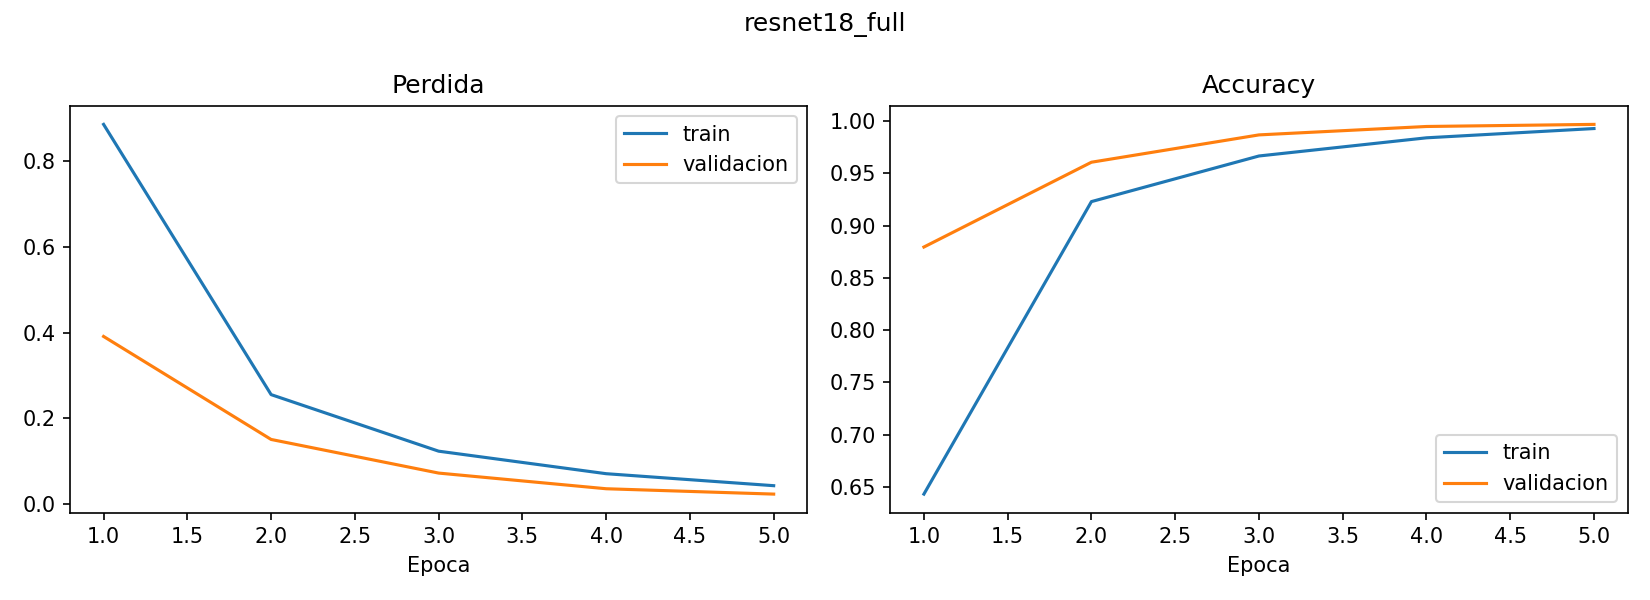

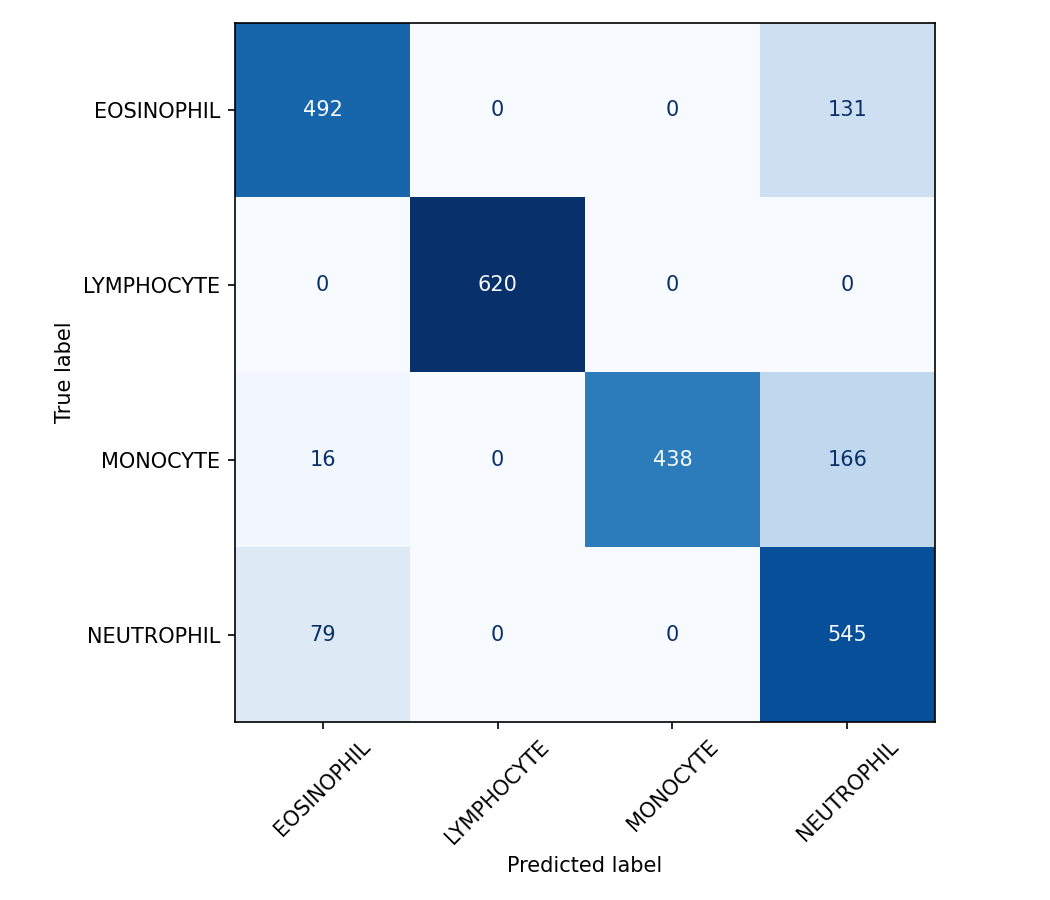

In [6]:
best_model = comparison.sort_values("test_accuracy", ascending=False).iloc[0]["model"]
display(Image(filename=str(RESULTS_DIR / "figures" / f"{best_model}_curves.png")))
display(Image(filename=str(RESULTS_DIR / "figures" / f"{best_model}_confusion_matrix.png")))

En un escenario medico con datos limitados, la recomendacion debe balancear accuracy, estabilidad y riesgo de sobreajuste. Fine-tuning parcial suele ser el compromiso mas razonable cuando mejora al mejor modelo desde cero sin actualizar todos los parametros de la red.